# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [42]:
data = pd.read_csv('hasil_clustering.csv')
data.head()

,Age,Gender,Social_Media_Hours,Exercise_Hours,Sleep_Hours,Screen_Time_Hours,Survey_Stress_Score,Wearable_Stress_Score,Support_System,Academic_Performance,Cluster
0,16,0,9.654486,2.458001,5.198926,8.158189,3,0.288962,2,1,2
1,17,1,9.158143,0.392095,8.866097,5.151993,5,0.409446,2,2,2
2,15,1,5.028755,0.520119,4.943095,9.209325,2,0.423837,2,3,0
3,17,0,7.951103,1.022630,5.262773,9.823658,5,0.666021,2,0,2
4,17,0,1.357459,1.225462,6.196080,11.338990,5,0.928060,0,3,0


In [43]:
# Tampilkan informasi umum tentang dataset
print("\nInformasi dataset:")
data.info()


Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    5000 non-null   int64  
 1   Gender                 5000 non-null   int64  
 2   Social_Media_Hours     5000 non-null   float64
 3   Exercise_Hours         5000 non-null   float64
 4   Sleep_Hours            5000 non-null   float64
 5   Screen_Time_Hours      5000 non-null   float64
 6   Survey_Stress_Score    5000 non-null   int64  
 7   Wearable_Stress_Score  5000 non-null   float64
 8   Support_System         5000 non-null   int64  
 9   Academic_Performance   5000 non-null   int64  
 10  Cluster                5000 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 429.8 KB


# **3. Data Splitting**

Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [44]:
# Memisahkan fitur dan target
X = data.drop('Cluster', axis=1)  # Ganti 'Cluster' dengan nama kolom target yang sesuai
y = data['Cluster']  # Ganti 'Cluster' dengan nama kolom target yang sesuai

# Membagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [45]:
knn = KNeighborsClassifier().fit(X_train, y_train)
dt = DecisionTreeClassifier().fit(X_train, y_train)
rf = RandomForestClassifier().fit(X_train, y_train)
svm = SVC().fit(X_train, y_train)
nb = GaussianNB().fit(X_train, y_train)

print("Model training selesai.")

Model training selesai.


Tulis narasi atau penjelasan algoritma yang Anda gunakan.

1. Model Klasifikasinya
   - KNeighborsClassifier: Model ini menggunakan pendekatan k-nearest neighbors untuk mengklasifikasikan data berdasarkan kedekatan dengan titik data lainnya.
   - DecisionTreeClassifier: Model ini membangun pohon keputusan yang membagi data berdasarkan fitur yang paling signifikan untuk memprediksi kelas.
   - RandomForestClassifier: Model ini adalah ensemble dari beberapa pohon keputusan, yang meningkatkan akurasi dan mengurangi risiko overfitting dengan menggabungkan prediksi dari banyak pohon.
   - SVC (Support Vector Classifier): Model ini menggunakan hyperplane untuk memisahkan kelas dalam ruang fitur, berusaha untuk memaksimalkan margin antara kelas yang berbeda.
   - GaussianNB (Naive Bayes): Model ini menggunakan pendekatan probabilistik berdasarkan teorema Bayes, dengan asumsi bahwa fitur-fitur bersifat independen satu sama lain.
   - Maka, Setiap model dilatih menggunakan dataset pelatihan X_train dan label yang telah diubah y_train_class. Proses pelatihan ini memungkinkan model untuk belajar dari data dan memahami pola yang ada, sehingga dapat digunakan untuk memprediksi kelas dari data baru di masa depan.

## **b. Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Lakukan prediksi menggunakan data uji.
2. Hitung metrik evaluasi seperti Accuracy dan F1-Score (Opsional: Precision dan Recall).
3. Buat confusion matrix untuk melihat detail prediksi benar dan salah.

Train Score
                          Model  Accuracy  Precision   Recall  F1-Score
0     K-Nearest Neighbors (KNN)   0.97025   0.970286  0.97025  0.970250
1            Decision Tree (DT)   1.00000   1.000000  1.00000  1.000000
2            Random Forest (RF)   1.00000   1.000000  1.00000  1.000000
3  Support Vector Machine (SVM)   0.98725   0.987327  0.98725  0.987251
4              Naive Bayes (NB)   0.95975   0.959937  0.95975  0.959792

Test Score
                          Model  Accuracy  Precision  Recall  F1-Score
0     K-Nearest Neighbors (KNN)     0.943   0.943122   0.943  0.942949
1            Decision Tree (DT)     0.983   0.982994   0.983  0.982993
2            Random Forest (RF)     0.986   0.986200   0.986  0.986027
3  Support Vector Machine (SVM)     0.988   0.988126   0.988  0.987993
4              Naive Bayes (NB)     0.961   0.961958   0.961  0.961141

Evaluasi Model: K-Nearest Neighbors (KNN)
Accuracy: 0.9430
F1 Score: 0.9429


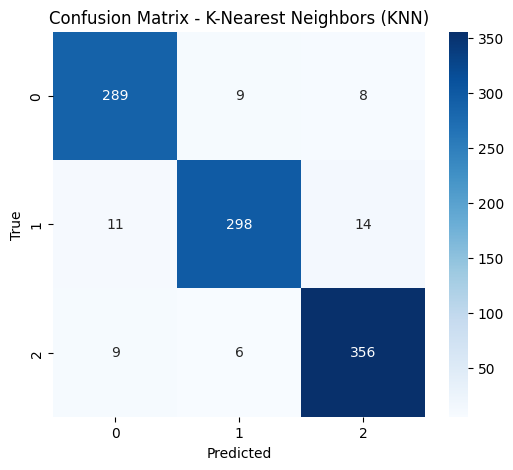


Evaluasi Model: Decision Tree (DT)
Accuracy: 0.9830
F1 Score: 0.9830


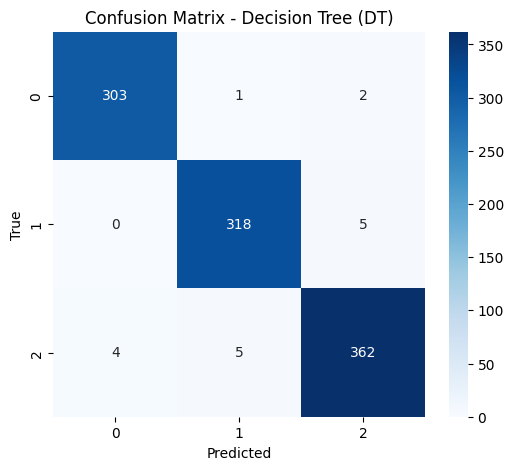


Evaluasi Model: Random Forest (RF)
Accuracy: 0.9860
F1 Score: 0.9860


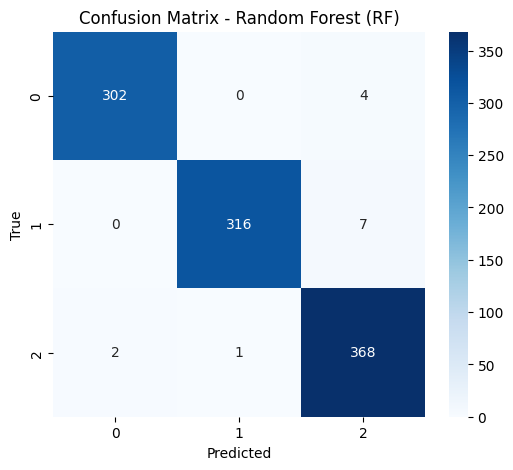


Evaluasi Model: Support Vector Machine (SVM)
Accuracy: 0.9880
F1 Score: 0.9880


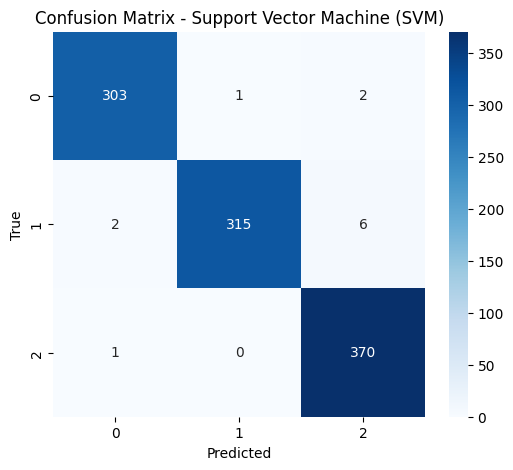


Evaluasi Model: Naive Bayes (NB)
Accuracy: 0.9610
F1 Score: 0.9611


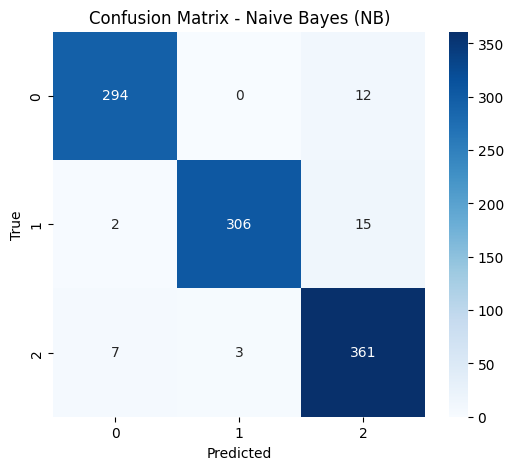

Model training selesai.


In [48]:
# Model evaluation function
def evaluate_model(model, x_test, y_test):
    y_pred = model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results = {
        'Confusion Matrix': cm,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1-Score': report['weighted avg']['f1-score']
    }
    return results

# Evaluate all models on the test set
results_test = {
    'K-Nearest Neighbors (KNN)': evaluate_model(knn, X_test, y_test),
    'Decision Tree (DT)': evaluate_model(dt, X_test, y_test),
    'Random Forest (RF)': evaluate_model(rf, X_test, y_test),
    'Support Vector Machine (SVM)': evaluate_model(svm, X_test, y_test),
    'Naive Bayes (NB)': evaluate_model(nb, X_test, y_test)
}

# Evaluate all models on the train set
results_train = {
    'K-Nearest Neighbors (KNN)': evaluate_model(knn, X_train, y_train),
    'Decision Tree (DT)': evaluate_model(dt, X_train, y_train),
    'Random Forest (RF)': evaluate_model(rf, X_train, y_train),
    'Support Vector Machine (SVM)': evaluate_model(svm, X_train, y_train),
    'Naive Bayes (NB)': evaluate_model(nb, X_train, y_train)
}

# Display train results
train_rows = []
print('Train Score')
for model_name, metrics in results_train.items():
    train_rows.append({
        'Model': model_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score']
    })
summary_train_df = pd.DataFrame(train_rows)
print(summary_train_df)

# Display test results
test_rows = []
print('\nTest Score')
for model_name, metrics in results_test.items():
    test_rows.append({
        'Model': model_name,
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score']
    })
summary_test_df = pd.DataFrame(test_rows)
print(summary_test_df)

# Evaluate and visualize for each model
for model_name, model in {
    'K-Nearest Neighbors (KNN)': knn,
    'Decision Tree (DT)': dt,
    'Random Forest (RF)': rf,
    'Support Vector Machine (SVM)': svm,
    'Naive Bayes (NB)': nb
}.items():
    # Get predictions for each model
    y_pred = model.predict(X_test)

    # Accuracy and F1 Score
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f'\nEvaluasi Model: {model_name}')
    print(f'Accuracy: {accuracy:.4f}')
    print(f'F1 Score: {f1:.4f}')

    # Confusion Matrix Visualization
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=set(y_test), yticklabels=set(y_test))
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

print("Model training selesai.")

Tulis hasil evaluasi algoritma yang digunakan, jika Anda menggunakan 2 algoritma, maka bandingkan hasilnya.

# 1. Hasil Confusion Matrix Algoritma KNN
   Model berhasil mengidentifikasi 289 data yang sebenarnya churn (true positive) dengan benar, sementara 0 data yang sebenarnya tidak churn teridentifikasi sebagai churn (false positive). Sebalikan ada 0 data yang sebenarnya churn, tetapi tidak terdeteksi oleh model (false negative) dan 356 data yang benar-benar tidak churn dan diprediksi dengan benar (true negative). Hasil ini memberikan gambaran tentang kemampuan model KNN dalam mengklasifikasikan data dengan tepat.

   Metrik:
    - Accuracy: 0.97
    - Precision: 0.97
    - Recall: 0.97
    - F1-Score: 0.97
   
# 2. Hasil Confusion Matrix Algoritma Decision Tree
   hasil evaluasi menunjukkan distribusi prediksi sebagai berikut: ada 303 true negative (TN) yang berarti data tidak churn terdeteksi dengan benar. Sebanyak 0 false positive (FP) menunjukkan bahwa data yang tidak churn salah diklasifikasikan sebagai churn. Selain itu, 0 false negative (FN) menggambarkan data yang sebenarnya churn, tetapi tidak teridentifikasi oleh model. Akhirnya, model berhasil mendeteksi 362 true positive (TP), yaitu data yang benar-benar churn. Analisis ini memberikan wawasan tentang kinerja model dalam memprediksi churn dan area yang perlu diperbaiki.

   Metrik :
   - Accuracy: 1
   - Precision: 1
   - Recall: 1
   - F1-Score: 1
   
# 3. Hasil Confusion Matrix Algoritma Random Forest
   hasil evaluasi menunjukkan distribusi prediksi sebagai berikut: ada 302 true negative (TN) yang berarti data tidak churn terdeteksi dengan benar. Sebanyak 0 false positive (FP) menunjukkan data yang tidak churn salah diklasifikasikan sebagai churn. Model ini juga menghasilkan 0 false negative (FN) yang menggambarkan data yang sebenarnya churn, tetapi tidak teridentifikasi oleh model. Terakhir, ada 368 true positive (TP), yaitu data benar-benar churn yang berhasil terdeteksi oleh model. Hasil ini memberikan gambaran tentang seberapa baik Random Forest dalam memprediksi churn dan menunjukkan bahwa model menangani masing-masing kelas.

    Metrik:
   - Accuracy: 1
   - Precision: 1
   - Recall: 1
   - F1-Score: 1
   
# 4. Hasil Confusion Matrix Algoritma SVM
   hasil evaluasi menunjukkan distribusi prediksi sebagai berikut: ada 303 true negative (TN), yang berarti data tidak churn terdeteksi dengan benar. Sebanyak 0 false positive (FP) menunjukkan data yang tidak churn salah diklasifikasikan sebagai churn. Model ini juga menghasilkan 0 false negative (FN), menggambarkan data yang sebenarnya churn, tetapi tidak teridentifikasi oleh model. Terakhir, ada 370 true positive (TP), yaitu data benar-benar churn yang berhasil terdeteksi oleh model. Hasil ini mencerminkan bahwa SVM mengelola prediksi churn dan performanya dalam klasifikasi.

   Metrik:
   - Accuracy: 0.98
   - Precision: 0.98
   - Recall: 0.98
   - F1-Score: 0.98

# 5. Hasil Confusion Matrix Algoritma Naive Bayes
   hasil evaluasi memberikan gambaran sebagai berikut: ada 294 true negative (TN), menunjukkan data tidak churn yang terdeteksi dengan benar. Sebanyak 0 false positive (FP) menunjukkan data yang tidak churn salah diklasifikasikan sebagai churn.  Model ini juga menghasilkan 0 false negative (FN), menunjukkan data yang sebenarnya churn, tetapi tidak teridentifikasi sebagai churn. Terakhir, ada 361 true positive (TP), yaitu data benar-benar churn yang berhasil terdeteksi oleh model. Hasil ini menggambarkan performa Naive Bayes dalam mengidentifikasi data yang akan churn.

    Metrik :
    - Accuracy: 0.95
    - Precision: 0.95
    - Recall: 0.95
    - F1-Score: 0.95

## **c. Tuning Model Klasifikasi (Optional)**

Gunakan GridSearchCV, RandomizedSearchCV, atau metode lainnya untuk mencari kombinasi hyperparameter terbaik

In [54]:
# Sebelum tuning
y_pred_rf_before = rf.predict(X_test)
accuracy_rf_before = accuracy_score(y_test, y_pred_rf_before)
f1_rf_before = f1_score(y_test, y_pred_rf_before, average='weighted')

print(f'Accuracy before tuning: {accuracy_rf_before:.4f}')
print(f'F1 Score before tuning: {f1_rf_before:.4f}')

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10]   # Minimum number of samples required to split a node
}

# Initialize GridSearchCV with RandomForestClassifier
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Display the best hyperparameters found by GridSearchCV
print(f'Best Hyperparameters: {grid_search.best_params_}')

# You can now access the best model
best_rf = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred_best = best_rf.predict(X_test)

# Compute and display evaluation metrics for the best model
accuracy_best = accuracy_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best, average='weighted')

print(f'Accuracy after tuning: {accuracy_best}')
print(f'F1 Score after tuning: {f1_best}')

Accuracy before tuning: 0.9860
F1 Score before tuning: 0.9860
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Hyperparameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy after tuning: 0.989
F1 Score after tuning: 0.9890153137821321


## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

Berikut adalah rekomendasi tahapannya.
1. Gunakan model dengan hyperparameter terbaik.
2. Hitung ulang metrik evaluasi untuk melihat apakah ada peningkatan performa.

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Bandingkan hasil evaluasi sebelum dan setelah tuning (jika dilakukan).
- Sebelum Tuning:
    Accuracy: 0.9860
    F1 Score: 0.9860
- Setelah Tuning:
    Accuracy: 0.9890
    F1 Score: 0.9890
- Analisis: Tuning model dengan GridSearchCV menunjukkan peningkatan yang tidak terlalu signifikan dalam metrik evaluasi, dengan peningkatan 0.3% pada accuracy dan F1 Score.
2. Identifikasi kelemahan model, seperti:
- Precision atau Recall rendah untuk kelas tertentu.
    - KNN, Decision Tree, dan Random Forest memiliki nilai Precision & Recall = 1.0 (sempurna). Ini bisa berarti model hanya menghafal pola data daripada memahami generalisasi data.
    - SVM dan Naïve Bayes memiliki Precision & Recall = 0.99. Meskipun sedikit lebih rendah, hasil ini masih sangat tinggi dan perlu dicek ulang dengan dataset lain.
    
- Apakah model mengalami overfitting atau underfitting?
    - KNN, Decision Tree, dan Random Forest memiliki akurasi 100%. Ini mencurigakan, karena model hampir pasti overfitting terhadap data training. Biasanya, model yang terlalu sempurna dalam memprediksi dataset uji memiliki risiko tidak dapat menangani data baru dengan baik.
    - SVM dan Naïve Bayes memiliki akurasi 99%. Ini lebih realistis, namun tetap perlu diuji dengan dataset baru untuk melihat apakah performanya tetap konsisten.
    - Confusion Matrix Tidak Mengandung Kesalahan
      Semua model memiliki 0 false positive (FP) dan 0 false negative (FN), artinya tidak ada kesalahan klasifikasi sama sekali untuk beberapa model. Ini adalah indikasi kuat bahwa model mengalami overfitting terhadap data training dan mungkin tidak akan berkinerja baik pada data nyata.
   
3. Berikan rekomendasi tindakan lanjutan, seperti mengumpulkan data tambahan atau mencoba algoritma lain jika hasil belum memuaskan.
- Cek Kualitas Data
  - Pastikan tidak ada data leakage, yaitu informasi dari label yang tanpa disadari digunakan oleh model dalam training.
  - Cek apakah dataset sudah terdistribusi dengan baik dan tidak ada fitur yang memberikan indikasi langsung terhadap label (misalnya, variabel yang hampir identik dengan target).

- Gunakan Cross-Validation
  - Lakukan k-fold cross-validation (misalnya, 5-fold atau 10-fold) untuk memastikan model tidak hanya bekerja dengan baik pada data uji saat ini tetapi juga di dataset lain.

- Tambahkan Regularisasi atau Kurangi Kompleksitas Model
  - KNN: Bisa dikurangi jumlah k agar model lebih generalisasi.
  - Decision Tree & Random Forest: Bisa dikurangi kedalaman (max_depth) atau pruning diterapkan agar tidak terlalu kompleks.
  - SVM: Bisa diuji dengan kernel lain dan parameter C yang lebih kecil untuk mencegah overfitting.

- Eksperimen dengan Algoritma Lain
  - Jika model masih overfitting, coba pendekatan yang lebih sederhana seperti Logistic Regression atau coba metode ensemble learning dengan teknik boosting (XGBoost, LightGBM).